In [1]:
import numpy as np
import pandas as pd
import multiprocessing as mp
import researchpy as rp
from inspect import signature
from matplotlib import pyplot as plt
from dacbench.logger import Logger, log2dataframe, load_logs
import seaborn as sns
import glob
from plotting import plot_performance_over_time, plot_final_performance_comparison, plot_improvement_probability, plot_configuration_footprint, plot_hp_importance, plot_deepcave

/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/dacbench/envs/__init__.py:35: UserWarning: CMA-ES Benchmark not installed. If you want to use this benchmark, please follow the installation guide.
  warnings.warn(  # noqa: B028


DACBench Gym registration failed - make sure you have all dependencies installed and their instance sets in the right path!


/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/dacbench/benchmarks/__init__.py:26: UserWarning: CMA-ES Benchmark not installed. If you want to use this benchmark, please follow the installation guide.
  warnings.warn(  # noqa: B028


In [3]:
def toDataFrame(glob_path, col_name, col_index, method):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d])

    df['method'] = method

    return df

def toChunkedDataFrame(glob_path, col_name, col_index, chunk_size):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d]).transpose()

    result_df = pd.DataFrame()
    for col in df.columns:
        reshaped_data = df[col].values.reshape(-1, chunk_size)
        result_df[col] = reshaped_data.mean(axis=1)

    result_df.reset_index()

    result_df['epoch'] = result_df.index + 1
    result_df = result_df.melt(id_vars=['epoch'])

    return result_df

sns.set_style('whitegrid')



   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9918  0.0004  0.0001     0.9915    0.9922


   Variable     N    Mean     SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9914  0.001  0.0003     0.9907    0.9921


   Variable    N    Mean      SD      SE  95% Conf.  Interval
0       0.0  9.0  0.9916  0.0007  0.0002     0.9911    0.9921


   Variable    N    Mean      SD      SE  95% Conf.  Interval
0       0.0  8.0  0.9847  0.0105  0.0037     0.9759    0.9935


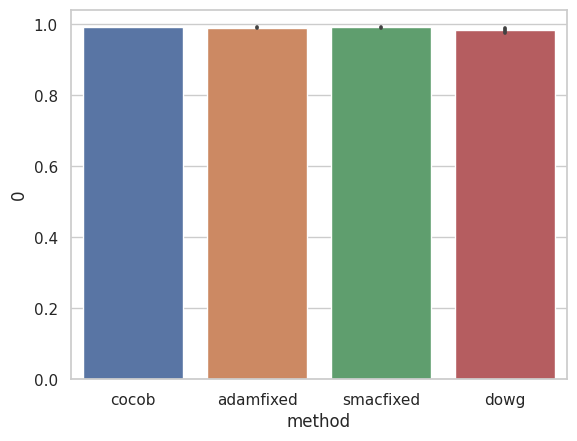

In [9]:
cocob_ta_mnist = toDataFrame('./results_cluster/results/COCOB_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_mnist = toDataFrame('./results_cluster/results/Adam_fixed_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
smacfixed_ta_mnist = toDataFrame('./results_cluster/results/SMAC_fixed_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
# cawr_ta_mnist = toDataFrame('./results_cluster/results/CAWR_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
# smacpolicy_ta_mnist = toDataFrame('./results_cluster/results/smacpolicy_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacpolicy')
dowg_ta_mnist = toDataFrame('./results_cluster/results/DoWG_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'dowg')
data = pd.concat([cocob_ta_mnist, adamfixed_ta_mnist, smacfixed_ta_mnist, dowg_ta_mnist])
sns.barplot(data=data, x='method', y=0)
print(rp.summary_cont(cocob_ta_mnist[0]))
print(rp.summary_cont(adamfixed_ta_mnist[0]))
print(rp.summary_cont(smacfixed_ta_mnist[0]))
# print(rp.summary_cont(cawr_ta_mnist[0]))
# print(rp.summary_cont(smacpolicy_ta_mnist[0]))
print(rp.summary_cont(dowg_ta_mnist[0]))



   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9244  0.0025  0.0008     0.9226    0.9261


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9265  0.0018  0.0006     0.9252    0.9277


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9191  0.0056  0.0018     0.9151    0.9231


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.8702  0.0737  0.0233     0.8174    0.9229


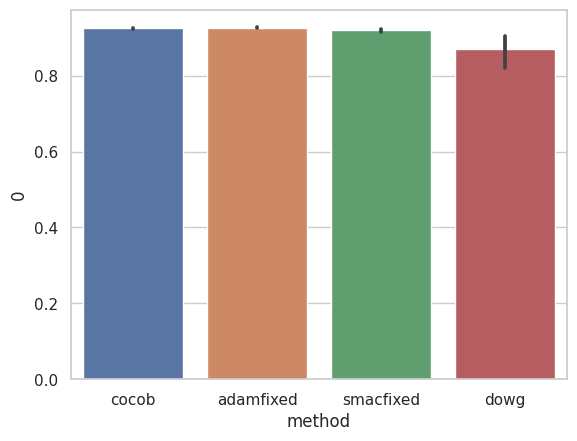

In [10]:
cocob_ta_fmnist = toDataFrame('./results_cluster/results/COCOB_fmnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_fmnist = toDataFrame('./results_cluster/results/Adam_fixed_fmnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
smacfixed_ta_fmnist = toDataFrame('./results_cluster/results/SMAC_fixed_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
# cawr_ta_fmnist = toDataFrame('./results_cluster/results/CAWR_fmnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
# smacpolicy_ta_fmnist = toDataFrame('./results_cluster/results/smacpolicy_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacpolicy')
dowg_ta_fmnist = toDataFrame('./results_cluster/results/DoWG_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'dowg')
data = pd.concat([cocob_ta_fmnist, adamfixed_ta_fmnist, smacfixed_ta_fmnist, dowg_ta_fmnist])
sns.barplot(data=data, x='method', y=0)
print(rp.summary_cont(cocob_ta_fmnist[0]))
print(rp.summary_cont(adamfixed_ta_fmnist[0]))
print(rp.summary_cont(smacfixed_ta_fmnist[0]))
# print(rp.summary_cont(cawr_ta_fmnist[0]))
# print(rp.summary_cont(smacpolicy_ta_fmnist[0]))
print(rp.summary_cont(dowg_ta_fmnist[0]))



   Variable     N    Mean    SD      SE  95% Conf.  Interval
0       0.0  10.0  0.8255  0.01  0.0032     0.8183    0.8327


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.8479  0.0078  0.0025     0.8423    0.8535


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.8538  0.0083  0.0026     0.8478    0.8597


   Variable     N   Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.841  0.0125  0.0039      0.832    0.8499


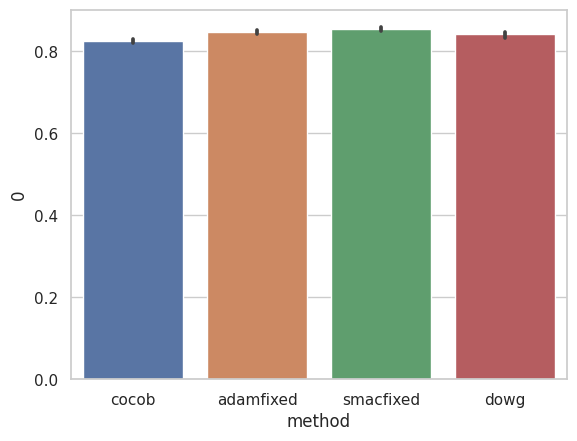

In [7]:
cocob_ta_cifar10 = toDataFrame('./results_cluster/results/COCOB_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_cifar10 = toDataFrame('./results_cluster/results/Adam_fixed_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
smacfixed_ta_cifar10 = toDataFrame('./results_cluster/results/SMAC_fixed_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
# smacpolicy_ta_cifar10 = toDataFrame('./results_cluster/results/smacpolicy_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacpolicy')
dowg_cifar10 = toDataFrame('./results_cluster/results/DoWG_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'dowg')
#cawr_ta_mnist = toDataFrame('./results_cluster/results/CAWR_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
data = pd.concat([cocob_ta_cifar10, adamfixed_ta_cifar10, smacfixed_ta_cifar10, dowg_cifar10])
sns.barplot(data=data, x='method', y=0)
print(rp.summary_cont(cocob_ta_cifar10[0]))
print(rp.summary_cont(adamfixed_ta_cifar10[0]))
print(rp.summary_cont(smacfixed_ta_cifar10[0]))
# print(rp.summary_cont(smacpolicy_ta_cifar10[0]))
print(rp.summary_cont(dowg_cifar10[0]))



   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.5406  0.0041  0.0013     0.5377    0.5436


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.5692  0.0057  0.0018     0.5651    0.5732


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.5742  0.0065  0.0021     0.5696    0.5789


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.5376  0.0057  0.0018     0.5335    0.5417


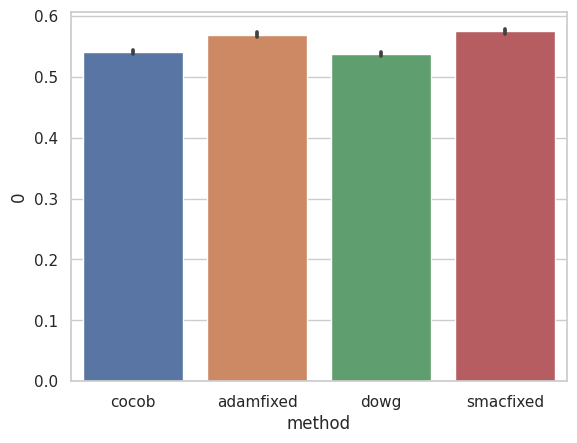

In [8]:
cocob_ta_cifar100 = toDataFrame('./results_cluster/results/COCOB_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_cifar100 = toDataFrame('./results_cluster/results/Adam_fixed_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
dowg_cifar100 = toDataFrame('./results_cluster/results/DoWG_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'dowg')
smacfixed_ta_cifar100 = toDataFrame('./results_cluster/results/SMAC_fixed_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
# smacpolicy_ta_cifar10 = toDataFrame('./results_cluster/results/smacpolicy_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacpolicy')
#cawr_ta_mnist = toDataFrame('./results_cluster/results/CAWR_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
data = pd.concat([cocob_ta_cifar100, adamfixed_ta_cifar100, dowg_cifar100, smacfixed_ta_cifar100])
sns.barplot(data=data, x='method', y=0)
print(rp.summary_cont(cocob_ta_cifar100[0]))
print(rp.summary_cont(adamfixed_ta_cifar100[0]))
print(rp.summary_cont(smacfixed_ta_cifar100[0]))
print(rp.summary_cont(dowg_cifar100[0]))

Text(0, 0.5, 'Learning Rate')

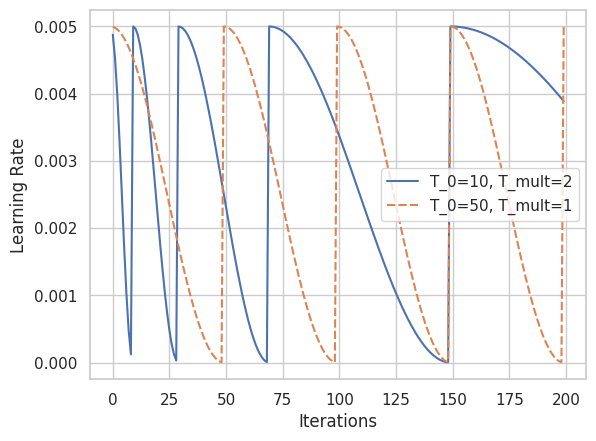

In [26]:
from dacbench_custom.cosine_annealing_agent import CosineAnnealingWRAgent as CAWR

def cawr_df(cawr):
    values = []
    for i in range(200):
        values.append(cawr.act())
    
    return pd.DataFrame(values)

cawr = CAWR(None, 10, 0, 0.005, 2)
cawr2 = CAWR(None, 50, 0, 0.005, 1)

df = pd.concat([cawr_df(cawr), cawr_df(cawr2)], axis=1)

df.columns = ['T_0=10, T_mult=2', 'T_0=50, T_mult=1']

sns.lineplot(data=df)
plt.xlabel('Iterations')
plt.ylabel('Learning Rate')